In [ ]:
# Usage Notes

# - Update `SPICE_SRC_PATH` and `ZARR_PATH` in the first code cell before running the notebook.
# - All user-configurable settings are collected in **Cell 9**. Modify parameters there only.
# - Available stellar parameters and their valid grid ranges are listed in **Cell 5**. Ensure perturbations remain within grid limits.
# - Running the notebook with a new parameter configuration creates a new output file automatically.
# - Re-running with the same configuration will overwrite the previous output file(s).
# - Plot labels, colorbars, filenames, and animations update automatically based on the selected parameter and wavelength range.

In [1]:
import jax
import sys

for mod in list(sys.modules):
    if mod.startswith("spice"):
        del sys.modules[mod]

SPICE_SRC_PATH = r"C:\Users\ASUS\Downloads\spice-main\spice-main\src"                              # ← replace with your path

ZARR_PATH      = r'C:\Users\ASUS\Downloads\fe_nlte_regular.zarr (1)\fe_nlte_regular.zarr'          # ← replace with your path


sys.path.insert(0, SPICE_SRC_PATH)

from spice.spectrum.lazy_zarr_interpolator import IntensityLazyZarrInterpolator
from spice.models import IcosphereModel
from spice.models.mesh_transform import add_rotation, evaluate_rotation
from spice.models.spots import add_spots, add_spot
from spice.plots import plot_3D
from spice.spectrum import simulate_observed_flux
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cmasher as cmr
from spice.spectrum.aemu_spectrum_emulator import IntensityPretrainedAemuSpectrumEmulator
import astro_emulators_toolkit as aemu

[spice] matplotlib loaded in 1.4 s


# Spotted star from Kochukhov (2017)

In [2]:
import zarr

g = zarr.open_group(ZARR_PATH
    
)

print(g.tree())

/
├── continuum (203070, 2001) float32
├── flux (203070, 2001) float32
├── global_index (203070,) int64
├── model_id (203070,) uint64
├── param_names (11,) <U32
├── params (203070, 11) float32
├── physics_hash (1,) <U72
├── provenance
│   ├── atmosphere_manifest.json (1,) StringDType()
│   ├── canonical_config.yaml (1,) StringDType()
│   ├── environment.txt (1,) StringDType()
│   ├── linelist_manifest.json (1,) StringDType()
│   ├── software_manifest.json (1,) StringDType()
│   └── synthesis_config.yaml (1,) StringDType()
├── schema_version (1,) <U16
└── wavelength (2001,) float32



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\zarr\core\group.py:576: ZarrUserWarning: Both zarr.json (Zarr format 3) and .zgroup (Zarr format 2) metadata objects exist at file://C:/Users/ASUS/Downloads/fe_nlte_regular.zarr (1)/fe_nlte_regular.zarr. Zarr format 3 will be used.
  warnings.warn(msg, category=ZarrUserWarning, stacklevel=1)


In [3]:
line_interp = IntensityLazyZarrInterpolator(
    ZARR_PATH,
    params=['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]', '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]', 'mu'],
    sparse=True
)

[spice] pandas loaded in 4.9 s


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\zarr\core\group.py:576: ZarrUserWarning: Both zarr.json (Zarr format 3) and .zgroup (Zarr format 2) metadata objects exist at file://C:/Users/ASUS/Downloads/fe_nlte_regular.zarr (1)/fe_nlte_regular.zarr. Zarr format 3 will be used.
  warnings.warn(msg, category=ZarrUserWarning, stacklevel=1)


[spice] Building sparse grid index...
[spice] Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 9.3 s


In [4]:
# parameters that can be varied with their bounds

for n, mn, mx in zip(
    line_interp._stellar_parameter_names,
    line_interp.min_stellar_parameters,
    line_interp.max_stellar_parameters
):
    print(f"{n:10s} {mn:8.3f} {mx:8.3f}")

teff       3800.000 8550.000
logg          0.000    5.000
[Fe/H]       -4.500    0.500
vmicro        0.000    5.000
[a/Fe]        0.000    0.000
[C/Fe]        0.000    0.000
[N/Fe]        0.000    0.000
[O/Fe]        0.000    0.000
[r/Fe]        0.000    0.000
[s/Fe]        0.000    0.000


In [5]:
import sys
print(sys.executable)

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\python.exe


In [6]:
m = IcosphereModel.construct(10000, 1.9, 1.5,
                             line_interp.to_parameters({'teff':8000, 'logg':4.0, '[Fe/H]':-4.0, 'vmicro':1.0}),
                             line_interp.stellar_parameter_names, override_log_g=False)


[spice] IcosphereModel constructed in 3.2 s


In [7]:
incl = 60.
# Calculate v_e from v_e*sin(incl) = 40 km/s
v_e_sin_i = 40.  # km/s
incl_rad = np.deg2rad(incl)
v_e = v_e_sin_i / np.sin(incl_rad)
print(f"v_e = {v_e:.2f} km/s (with v_e*sin(i) = {v_e_sin_i} km/s at inclination {incl}°)")

v_e = 46.19 km/s (with v_e*sin(i) = 40.0 km/s at inclination 60.0°)


In [9]:
# ══ EXPERIMENT CONFIG — change only here ══════════════════

SPOT_LATS    = [-30, 0, 30, 60]      # degrees, one per spot
SPOT_LONS    = [-90, 0, 90, 180]     # degrees, one per spot
SPOT_RADIUS  = 25.                   # angular radius in degrees (try 10 for small, 40 for large)
DELTA        = -1000                 # abundance enhancement (positive = more metal-rich)
PARAM_INDEX  = 0                     # 0=teff, 1=logg, 2=[Fe/H], 3=vmicro
SMOOTHNESS   = 0.5                   # spot edge: 0=hard, 1=very diffuse

WL_START     = 5010                  # wavelength range start (Å)
WL_END       = 5020                  # wavelength range end (Å)
N_WL         = 50                   # number of wavelength points

# ══════════════════════════════════════════════════════════

In [16]:
PARAM_LABELS = {
    0: "Teff (K)",
    1: "log g",
    2: "[Fe/H]",
    3: "vmicro",
    4: "[α/Fe]",
    5: "[C/Fe]",
    6: "[N/Fe]",
    7: "[O/Fe]",
    8: "[r/Fe]",
    9: "[s/Fe]",
    10: "μ"
}

In [ ]:
from spice.models.mesh_view import get_mesh_view
from spice.models.utils import inclination_to_los_axis, lat_to_theta, lon_to_phi, velocity_to_period

period_seconds = velocity_to_period(v_e, m.radius)
timestamps = jnp.linspace(0, period_seconds, 25)

# Convert inclination to LOS vector
mt = get_mesh_view(add_rotation(m, v_e), los_vector=inclination_to_los_axis(incl))

SPOT_RADIUS = 25.


ms = add_spots(mt,
               spot_center_thetas=jnp.array([lat_to_theta(lat) for lat in SPOT_LATS]),
               spot_center_phis=jnp.array([lon_to_phi(lon) for lon in SPOT_LONS]),
               spot_radii=jnp.array(len(SPOT_LATS) * [SPOT_RADIUS]),
               parameter_deltas=jnp.array(len(SPOT_LATS) * [DELTA]),
               parameter_indices=jnp.array(len(SPOT_LATS) * [PARAM_INDEX]),
               smoothness=jnp.array(len(SPOT_LATS) * [SMOOTHNESS]))

ms_min10 = add_spot(mt, spot_center_theta=lat_to_theta(SPOT_LATS[0]),
               spot_center_phi=lon_to_phi(SPOT_LONS[0]),
               spot_radius=SPOT_RADIUS, parameter_delta=DELTA,
               parameter_index=PARAM_INDEX, smoothness=SMOOTHNESS)

ms_10 = add_spot(mt, spot_center_theta=lat_to_theta(SPOT_LATS[1]),
               spot_center_phi=lon_to_phi(SPOT_LONS[1]),
               spot_radius=SPOT_RADIUS, parameter_delta=DELTA,
               parameter_index=PARAM_INDEX, smoothness=SMOOTHNESS)

ms_20 = add_spot(mt, spot_center_theta=lat_to_theta(SPOT_LATS[2]),
               spot_center_phi=lon_to_phi(SPOT_LONS[2]),
               spot_radius=SPOT_RADIUS, parameter_delta=DELTA,
               parameter_index=PARAM_INDEX, smoothness=SMOOTHNESS)

ms_30 = add_spot(mt, spot_center_theta=lat_to_theta(SPOT_LATS[3]),
               spot_center_phi=lon_to_phi(SPOT_LONS[3]),
               spot_radius=SPOT_RADIUS, parameter_delta=DELTA,
               parameter_index=PARAM_INDEX, smoothness=SMOOTHNESS)




In [11]:
from tqdm import tqdm

In [12]:
mts = [evaluate_rotation(ms, t) for t in tqdm(timestamps)]
mts_min10 = [evaluate_rotation(ms_min10, t) for t in tqdm(timestamps)]
mts_10 = [evaluate_rotation(ms_10, t) for t in tqdm(timestamps)]
mts_20 = [evaluate_rotation(ms_20, t) for t in tqdm(timestamps)]
mts_30 = [evaluate_rotation(ms_30, t) for t in tqdm(timestamps)]

100%|██████████| 25/25 [00:00<00:00, 422.23it/s]


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


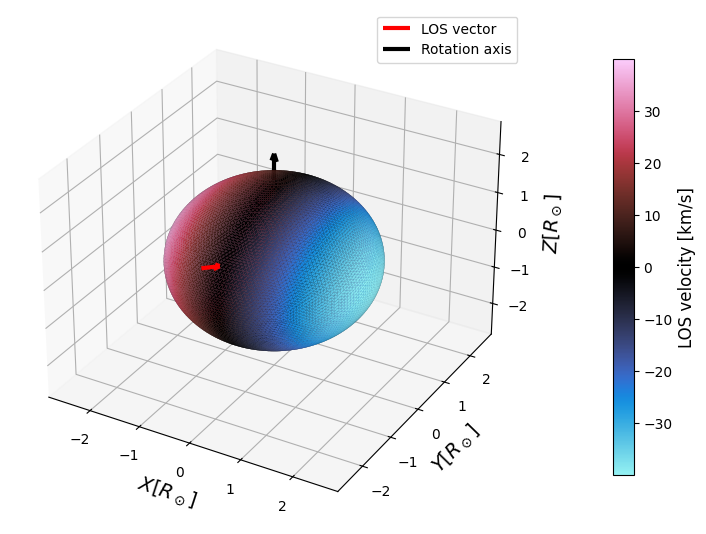

In [13]:
fig, _ = plot_3D(mts[0], 'los_velocities');

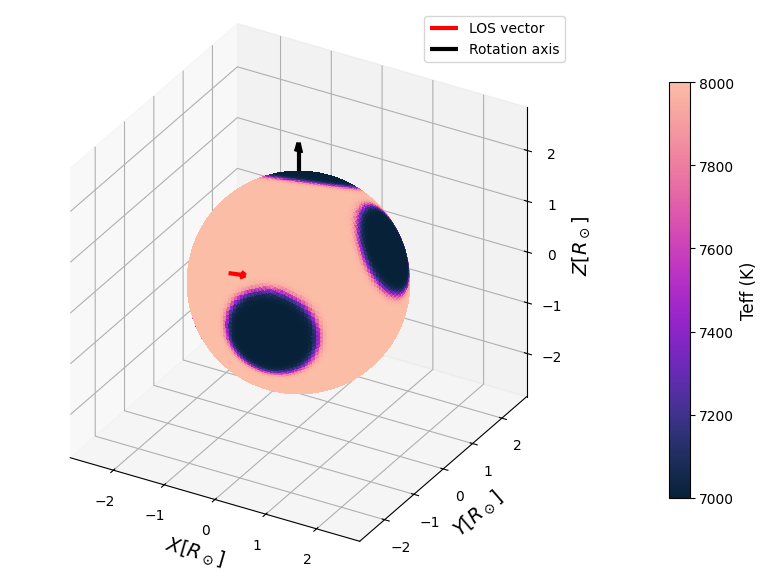

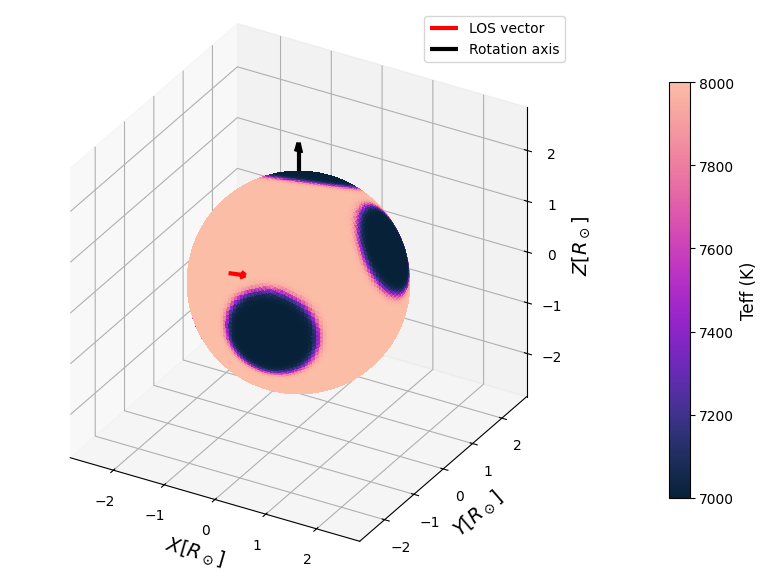

In [17]:
import matplotlib as mpl
from mpl_toolkits.mplot3d import art3d
from spice.plots.plot_mesh import (
    DEFAULT_CMAP,
    _mesh_center,
    _set_axes_centered,
    _single_mesh_arrow_vectors,
)

mesh = mts[5]
fe_h = np.asarray(mesh.parameters[:, PARAM_INDEX])
cmap = DEFAULT_CMAP
vmin, vmax = fe_h.min(), fe_h.max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig_fe = plt.figure(figsize=(10, 12))
ax_fe = fig_fe.add_subplot(projection="3d")
ax_fe.set_proj_type("ortho")

face_colors = mpl.colormaps[cmap](norm(fe_h))
ax_fe.add_collection(art3d.Poly3DCollection(
    mesh.mesh_elements,
    facecolors=face_colors,
    edgecolor="none",
    linewidths=0,
    antialiased=False,
))

center = _mesh_center(mesh)
axes_lim = 1.5 * float(mesh.radius)
_set_axes_centered(ax_fe, center, axes_lim)
ax_fe.set_xlabel("$X [R_\\odot]$", fontsize=14)
ax_fe.set_ylabel("$Y [R_\\odot]$", fontsize=14)
ax_fe.set_zlabel("$Z [R_\\odot]$", fontsize=14)
ax_fe.set_box_aspect((1, 1, 1))

los_start, los_vec, rotation_start, rotation_vec = _single_mesh_arrow_vectors(mesh)
ax_fe.quiver(*los_start, *los_vec, color="red", linewidth=3.0, label="LOS vector")
ax_fe.quiver(*rotation_start, *rotation_vec, color="black", linewidth=3.0, label="Rotation axis")
ax_fe.legend()

ax_fe.view_init(elev=30, azim=-60)

mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array([])
cbar = fig_fe.colorbar(mappable, shrink=0.45, pad=0.125, ax=ax_fe)
cbar.set_label(PARAM_LABELS[PARAM_INDEX], fontsize=12)
fig_fe

In [21]:
fig_fe.savefig(
    f"kochukov_2017_param{PARAM_INDEX}_delta{DELTA}.pdf",
    bbox_inches="tight"
)

In [ ]:
vws = jnp.linspace(WL_START, WL_END, N_WL)

spec = []
spec_min10 = []
spec_10 = []
spec_20 = []
spec_30 = []

for i in tqdm(range(len(mts))):
    spec.append(simulate_observed_flux(line_interp.intensity, mts[i], jnp.log10(vws)))
    spec_min10.append(simulate_observed_flux(line_interp.intensity, mts_min10[i], jnp.log10(vws)))
    spec_10.append(simulate_observed_flux(line_interp.intensity, mts_10[i], jnp.log10(vws)))
    spec_20.append(simulate_observed_flux(line_interp.intensity, mts_20[i], jnp.log10(vws)))
    spec_30.append(simulate_observed_flux(line_interp.intensity, mts_30[i], jnp.log10(vws)))

spec_flux = np.stack([np.asarray(s[:, 0]) for s in spec])
pairwise = [np.max(np.abs(spec_flux[i] - spec_flux[j]))
            for i in range(len(spec)) for j in range(i + 1, len(spec))]
print(f'max pairwise flux difference across phases: {max(pairwise):.6e}')
print(f'los_velocities std (phase 0 / mid / last):',
      [float(np.std(np.asarray(mts[k].los_velocities))) for k in (0, len(mts)//2, -1)])


  0%|          | 0/25 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\jax\_src\numpy\array_methods.py:124: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
100%|██████████| 25/25 [23:46<00:00, 57.05s/it]


max pairwise flux difference across phases: 4.830625e-11
los_velocities std (phase 0 / mid / last): [23.08987808227539, 23.08987808227539, 23.08987808227539]


In [27]:
spec = np.array(spec)

In [28]:
import pickle

# Save all spectra arrays to a pickle file
spectra_data = {
    'wavelengths': vws,
    'spec': spec,
    'spec_min10': spec_min10,
    'spec_10': spec_10,
    'spec_20': spec_20,
    'spec_30': spec_30,
    'timestamps': timestamps
}

with open('kochukov2017_spectra.pkl', 'wb') as f:
    pickle.dump(spectra_data, f)

print("Spectra saved to kochukov2017_spectra.pkl")

Spectra saved to kochukov2017_spectra.pkl


In [29]:
 import pickle

 with open('kochukov2017_spectra.pkl', 'rb') as f:
     loaded_spectra = pickle.load(f)

 print("Loaded keys from pickle:", loaded_spectra.keys())
 wavelengths = loaded_spectra['wavelengths']
 spec = loaded_spectra['spec']
 spec_min10 = loaded_spectra['spec_min10']
 spec_10 = loaded_spectra['spec_10']
 spec_20 = loaded_spectra['spec_20']
 spec_30 = loaded_spectra['spec_30']
#  spec_em = loaded_spectra['spec_nlte']
#  spec_min10_em = loaded_spectra['spec_min10_nlte']
#  spec_10_em = loaded_spectra['spec_10_nlte']
#  spec_20_em = loaded_spectra['spec_20_nlte']
#  spec_30_em = loaded_spectra['spec_30_nlte']
#  timestamps = loaded_spectra['timestamps']

Loaded keys from pickle: dict_keys(['wavelengths', 'spec', 'spec_min10', 'spec_10', 'spec_20', 'spec_30', 'timestamps'])


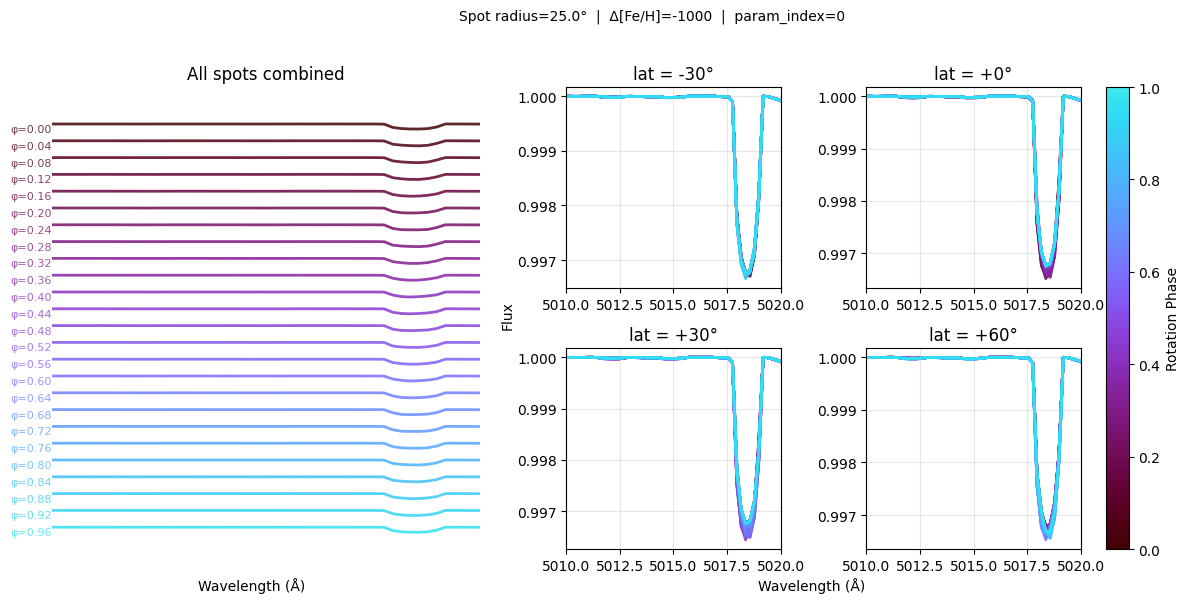

In [31]:
# Create figure with 5 subplots: 1 custom row-by-row on left, 4 smaller in 2x2 grid on right
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 3, width_ratios=[2, 1, 1], hspace=0.3, wspace=0.3)

ax_main = fig.add_subplot(gs[:, 0])
ax_main.axis('off')

ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

lim_start = WL_START        # ← was 5000
lim_end = WL_END            # ← was 5004
#xticks = list(range(int(WL_START), int(WL_END) + 1))   # ← was hardcoded list
xticks = np.linspace(WL_START, WL_END, 5)
linewidth = 2
alpha = 0.85

cmap = cmr.gem
colors = [cmap(i / len(spec)) for i in range(len(spec))]

# ---- Left pane: all spots combined ----
n = len(spec)
row_height = 1.0 / n
y0 = 0.95
for i in range(n):
    y = y0 - i * row_height
    norm_flux = spec[i][:, 0] / spec[i][:, 1]
    prof_scale = 0.3 * row_height
    baseline = y
    offset_flux = baseline + (norm_flux - norm_flux.min()) * (prof_scale / (norm_flux.max() - norm_flux.min() + 1e-8))
    ax_main.plot(vws, offset_flux, color=colors[i], alpha=alpha, linewidth=linewidth)
    ax_main.text(lim_start, baseline, f"φ={i/n:.2f}", va='center', ha='right', fontsize=8, color=colors[i], alpha=0.75)

ax_main.set_xlim(lim_start, lim_end)
ax_main.set_ylim(-0.05, 1.05)
ax_main.set_title('All spots combined')

# ---- Right panels: one per spot ----
spot_specs = [spec_min10, spec_10, spec_20, spec_30]   # ← update this list if spot variables change
axes = [ax1, ax2, ax3, ax4]

for i in range(n):
    for ax, sp in zip(axes, spot_specs):
        ax.plot(vws, sp[i][:, 0] / sp[i][:, 1], alpha=alpha, color=colors[i], linewidth=linewidth)

# Titles pull from SPOT_LATS in config
for ax, lat in zip(axes, SPOT_LATS):            # ← was hardcoded 'i=-30°' etc.
    ax.set_title(f'lat = {lat:+.0f}°')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lim_start, lim_end)
    ax.set_xticks(xticks)

# Labels
fig.suptitle(
    f'Spot radius={SPOT_RADIUS}°  |  Δ[Fe/H]={DELTA}  |  param_index={PARAM_INDEX}',
    fontsize=10, y=1.01
)
fig.text(0.25, 0.05, 'Wavelength (Å)', ha='center', va='center')
fig.text(0.6,  0.05, 'Wavelength (Å)', ha='center', va='center')
fig.text(0.41, 0.5,  'Flux', ha='center', va='center', rotation='vertical')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_main, ax1, ax2, ax3, ax4], orientation='vertical', pad=0.02)
cbar.set_label('Rotation Phase')

plt.show()

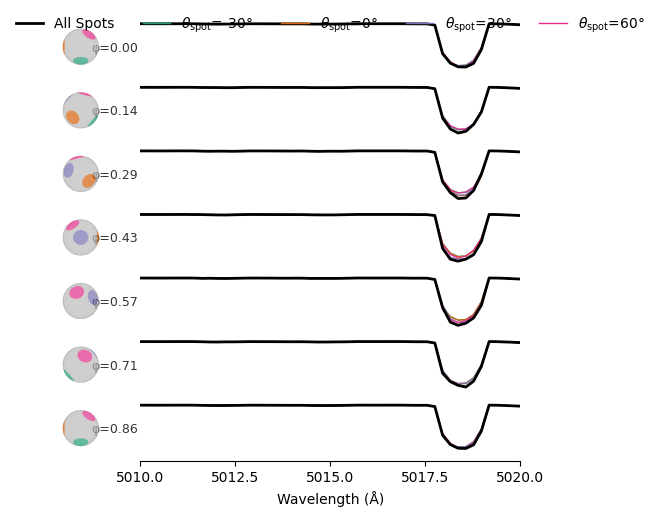

In [33]:
# Row-per-phase figure: combined spectrum in bold + individual spot contributions thinner
# plus a small 3D mesh inset on the left of each row showing what spots are
# visible at the corresponding rotation phase.
import matplotlib as mpl
from mpl_toolkits.mplot3d import art3d
from spice.plots.plot_mesh import _mesh_center, _set_axes_centered

fig, ax = plt.subplots(figsize=(5, 5))
ax.axis('off')
# Leave room on the left for small 3D mesh insets
fig.subplots_adjust(left=0.22, right=0.98, top=0.95, bottom=0.06)

lim_start = WL_START
lim_end = WL_END

# Same spot colors as in the animation
spot_colors = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A"]
spot_labels = ['$\\theta_{\\rm{spot}}$=-30°', '$\\theta_{\\rm{spot}}$=0°', '$\\theta_{\\rm{spot}}$=30°', '$\\theta_{\\rm{spot}}$=60°']

stride = 4

spot_specs = [spec_min10[::stride], spec_10[::stride], spec_20[::stride], spec_30[::stride]]

combined_color = 'black'
combined_lw = 2.0
spot_lw = 1.0
spot_alpha = 0.9
combined_alpha = 1.0

spec_to_plot = spec[::stride]
mts_to_plot = mts[::stride]
n = len(spec_to_plot)

# Normalize once globally so rows (phases) are directly comparable and
# relative depths between combined and individual contributions are preserved.
all_curves = []
for i in range(n):
    all_curves.append(spec_to_plot[i][:, 0] / spec_to_plot[i][:, 1])
    for sp in spot_specs:
        all_curves.append(sp[i][:, 0] / sp[i][:, 1])
all_curves = np.asarray(all_curves)
g_min = all_curves.min()
g_max = all_curves.max()
g_range = g_max - g_min + 1e-12

row_height = 1.0 / n
prof_scale = 0.75 * row_height
y0 = 1.0 - row_height / 2

def to_row(flux, baseline):
    return baseline + (flux - g_min) * (prof_scale / g_range) - prof_scale / 2

for i in range(n):
    baseline = y0 - i * row_height

    for sp, col in zip(spot_specs, spot_colors):
        flux = sp[i][:, 0] / sp[i][:, 1]
        ax.plot(vws, to_row(flux, baseline), color=col, alpha=spot_alpha,
                linewidth=spot_lw)

    combined = spec_to_plot[i][:, 0] / spec_to_plot[i][:, 1]
    ax.plot(vws, to_row(combined, baseline), color=combined_color,
            alpha=combined_alpha, linewidth=combined_lw)

    phase = i / n
    ax.text(lim_start - 0.05, baseline, f"φ={phase:.2f}",
            va='center', ha='right', fontsize=9, color='0.2')

ax.set_xlim(lim_start, lim_end)
ax.set_ylim(0, 1)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=combined_color, linewidth=combined_lw, label='All Spots'),
] + [
    Line2D([0], [0], color=c, linewidth=spot_lw, label=lbl)
    for c, lbl in zip(spot_colors, spot_labels)
]
ax.legend(handles=legend_handles, loc='upper center',
          bbox_to_anchor=(0.5, 1.03), ncol=5, frameon=False)

ax_x = ax.twiny()
ax_x.set_xlim(lim_start, lim_end)
ax_x.xaxis.set_ticks_position('bottom')
ax_x.xaxis.set_label_position('bottom')
ax_x.spines['top'].set_visible(False)
ax_x.spines['left'].set_visible(False)
ax_x.spines['right'].set_visible(False)
ax_x.set_yticks([])
# ax_x.set_xticks([5000, 5001, 5002, 5003, 5004])
ax_x.set_xticks(
    np.linspace(WL_START, WL_END, 5))
ax_x.set_xlabel('Wavelength (Å)')

# --- 3D mesh insets on the left, one per phase row ---
# Color faces by their dominant spot so the 3D spots match the corresponding
# spectrum line colors. Face indices don't change under rotation, so we
# compute the per-face spot assignment once on the unrotated multi-spot mesh
# `ms` and reuse it for every phase.
from spice.models.spots import generate_spherical_spot

_spot_lats_deg = SPOT_LATS
_spot_lons_deg = SPOT_LONS
_spot_contribs = np.stack([
    np.asarray(generate_spherical_spot(
        ms.d_centers, ms.radius,
        lat_to_theta(lat), lon_to_phi(lon),
        SPOT_RADIUS, 1.0, 0.5,
    ))
    for lat, lon in zip(_spot_lats_deg, _spot_lons_deg)
], axis=1)  # (n_faces, n_spots)
_best_spot = np.argmax(_spot_contribs, axis=1)
_best_contrib = np.take_along_axis(
    _spot_contribs, _best_spot[:, None], axis=1
).squeeze(-1)
# Sigmoid half-value marks the nominal spot edge; weaker faces are unspotted.
_unspotted_mask = _best_contrib < 0.5
_spot_rgba = np.array([mpl.colors.to_rgba(c) for c in spot_colors])
_base_color = np.array(mpl.colors.to_rgba('0.75'))
_face_spot_colors = _spot_rgba[_best_spot]
_face_spot_colors[_unspotted_mask] = _base_color


def _los_view_angles(mesh):
    # Return matplotlib (elev, azim) in degrees such that the camera position
    # lies along mesh.los_vector (the direction from the star toward the
    # observer). Matplotlib's camera position is
    #   (cos(elev)cos(azim), cos(elev)sin(azim), sin(elev)).
    # Solving for the LOS direction gives:
    #   elev = arcsin(los_z),   azim = arctan2(los_y, los_x).
    # With inclination_to_los_axis(i) = (0, sin i, -cos i), an inclination of
    # e.g. 60 deg yields elev = -30 deg, azim = 90 deg, i.e. the star is
    # viewed 30 deg below the equator with the rotation axis tilted away.
    los = np.array(mesh.los_vector, dtype=float)
    los = los / (np.linalg.norm(los) + 1e-12)
    elev = float(np.degrees(np.arcsin(np.clip(los[2], -1.0, 1.0))))
    azim = float(np.degrees(np.arctan2(los[1], los[0])))
    return elev, azim


ax_pos = ax.get_position()
inset_h = 0.95 * row_height * ax_pos.height
# Keep insets square in inches by compensating for figure aspect ratio.
inset_w = inset_h * fig.get_figheight() / fig.get_figwidth()
inset_right = ax_pos.x0 - 0.06  # leave room for the φ=... label
inset_left = max(0.005, inset_right - inset_w)

for i, mesh in enumerate(mts_to_plot):
    baseline = y0 - i * row_height
    fig_y = ax_pos.y0 + baseline * ax_pos.height
    inset_ax = fig.add_axes(
        [inset_left, fig_y - inset_h / 2, inset_w, inset_h],
        projection='3d',
    )
    inset_ax.set_axis_off()
    # Orthographic projection so the inclination isn't distorted by the default
    # matplotlib perspective at small inset sizes.
    inset_ax.set_proj_type('ortho')
    inset_ax.patch.set_alpha(0.0)

    # Hide non-visible faces so only the observer-facing hemisphere is drawn.
    mus = np.asarray(mesh.mus)
    visible = mus > 0
    face_colors = _face_spot_colors.copy()
    face_colors[~visible] = (0.0, 0.0, 0.0, 0.0)

    p = art3d.Poly3DCollection(
        mesh.mesh_elements,
        facecolors=face_colors,
        edgecolor='none',
        linewidths=0,
    )
    inset_ax.add_collection(p)

    center = _mesh_center(mesh)
    _set_axes_centered(inset_ax, center, 1.0 * float(mesh.radius))
    inset_ax.set_box_aspect((1, 1, 1))
    # Apply the LOS-derived view AFTER the box aspect / limits so it isn't
    # overwritten by later autoscale decisions.
    elev, azim = _los_view_angles(mesh)
    inset_ax.view_init(elev=elev, azim=azim)

plt.show()


TODO: color spots

In [39]:
# Save the figure as PDF
fig.savefig(f'kochukov2017_spectra_comparison_{PARAM_INDEX}_{DELTA}_nlte.pdf', bbox_inches='tight', dpi=300)
print(f"Figure saved to kochukov2017_spectra_comparison_{PARAM_INDEX}_{DELTA}_nlte.pdf")

Figure saved to kochukov2017_spectra_comparison_0_-1000_nlte.pdf


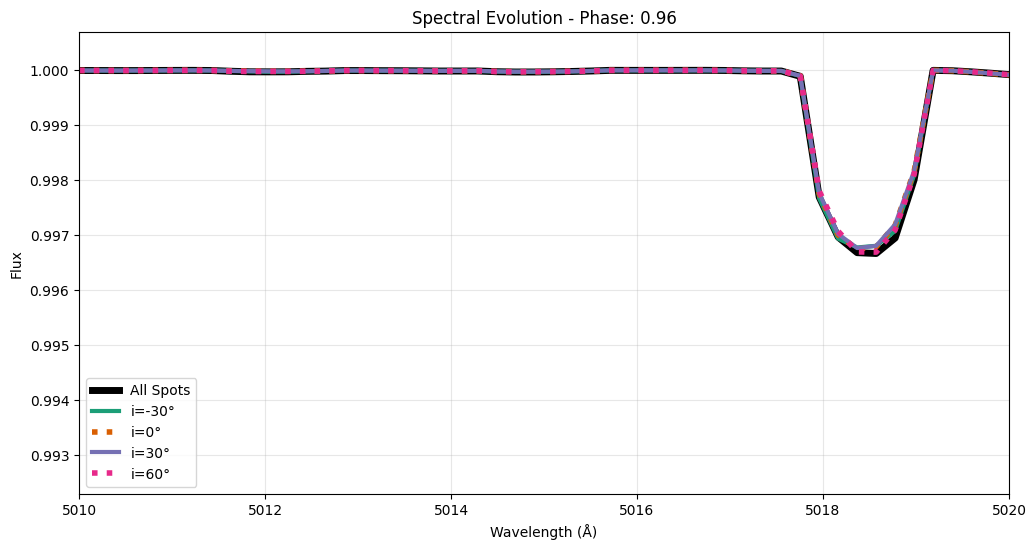

In [35]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create figure for animation
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A"]

# Initialize empty lines for each inclination
line_main, = ax.plot([], [], color='black', label='All Spots', linewidth=5)
line_min10, = ax.plot([], [], color=colors[0], label='i=-30°', linewidth=3)
line_10, = ax.plot([], [], color=colors[1], label='i=0°', linewidth=4, linestyle='dotted')
line_20, = ax.plot([], [], color=colors[2], label='i=30°', linewidth=3)
line_30, = ax.plot([], [], color=colors[3], label='i=60°', linewidth=4, linestyle='dotted')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux')
ax.set_title('Spectral Evolution - Phase: 0.00')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Set axis limits based on data
ax.set_xlim(vws[0], vws[-1])
all_specs = spec + spec_min10 + spec_10 + spec_20 + spec_30
y_min = 0.993
y_max = 1.
y_range = y_max - y_min
ax.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)
ax.set_xlim(WL_START, WL_END)

def init():
    line_main.set_data([], [])
    line_min10.set_data([], [])
    line_10.set_data([], [])
    line_20.set_data([], [])
    line_30.set_data([], [])
    return line_main, line_min10, line_10, line_20, line_30

def animate(frame):
    line_main.set_data(vws, spec[frame][:, 0]/spec[frame][:, 1])
    line_min10.set_data(vws, spec_min10[frame][:, 0]/spec_min10[frame][:, 1])
    line_10.set_data(vws, spec_10[frame][:, 0]/spec_10[frame][:, 1])
    line_20.set_data(vws, spec_20[frame][:, 0]/spec_20[frame][:, 1])
    line_30.set_data(vws, spec_30[frame][:, 0]/spec_30[frame][:, 1])
    
    # Update title with current phase
    phase = frame / len(spec)
    ax.set_title(f'Spectral Evolution - Phase: {phase:.2f}')
    
    return line_main, line_min10, line_10, line_20, line_30

# Create animation
anim = FuncAnimation(fig, animate, init_func=init, frames=len(spec), 
                     interval=200, blit=True, repeat=True)

# Display animation in notebook
HTML(anim.to_jshtml())

In [ ]:
# Save animation to file
anim.save(f'spectral_{PARAM_INDEX}_{DELTA}_evolution.gif', writer='pillow', fps=5, dpi=100)
print(f"Animation saved to spectral_{PARAM_INDEX}_{DELTA}_evolution.gif")

Animation saved to spectral_{PARAM_INDEX}_{DELTA}_evolution.gif


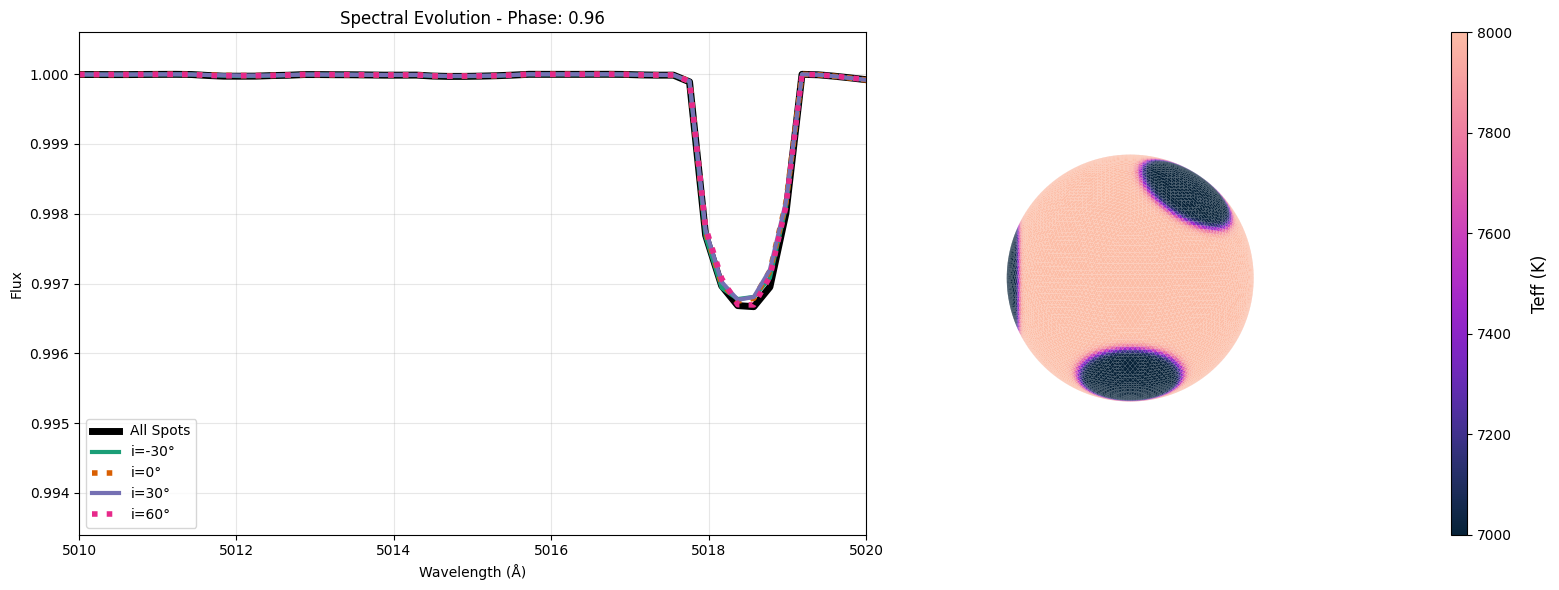

In [37]:
from spice.plots.plot_mesh import *
import numpy as np

def _evaluate_to_be_mapped_property(mesh,
                                    property = DEFAULT_PROPERTY,
                                    property_label = None):
    """
    Evaluate the property to be mapped in visualization.
    (Implementation unchanged)
    """
    if isinstance(property, str):
        if property in DEFAULT_PLOT_PROPERTY_LABELS:
            to_be_mapped = getattr(mesh, property)
            if property_label is None:
                property_label = DEFAULT_PLOT_PROPERTY_LABELS[property]
        elif hasattr(mesh, property):
            to_be_mapped = getattr(mesh, property)
            if property_label is None:
                property_label = property
        else:
            raise ValueError(f'Invalid property {property} - must be an attribute of MeshModel or one of {list(DEFAULT_PLOT_PROPERTY_LABELS.keys())}')
    elif isinstance(property, int):
        if property > mesh.parameters.shape[-1]-1:
            raise ValueError(f'Invalid property index {property} - must be smaller than {mesh.parameters.shape[-1]}')
        to_be_mapped = mesh.parameters[:, property]
        if property_label is None:
            property_label = ''
    else:
        raise ValueError(f"Property must be either of type str or int")
    return to_be_mapped, property_label

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

colors = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A"]

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 4, width_ratios=[3., 1.55, 0.05, 0.06])

# SPECTRUM: Left panel
ax_spec = fig.add_subplot(gs[0])
ax_spec.set_xlabel('Wavelength (Å)')
ax_spec.set_ylabel('Flux')
ax_spec.set_title('Spectral Evolution - Phase: 0.00')

line_main, = ax_spec.plot([], [], color='black', label='All Spots', linewidth=5)
line_min10, = ax_spec.plot([], [], color=colors[0], label='i=-30°', linewidth=3)
line_10, = ax_spec.plot([], [], color=colors[1], label='i=0°', linewidth=4, linestyle='dotted')
line_20, = ax_spec.plot([], [], color=colors[2], label='i=30°', linewidth=3)
line_30, = ax_spec.plot([], [], color=colors[3], label='i=60°', linewidth=4, linestyle='dotted')

spec_legend = ax_spec.legend(loc='best')
ax_spec.grid(True, alpha=0.3)
ax_spec.set_xlim(WL_START, WL_END)
y_min = 0.994
y_max = 1.
y_range = y_max - y_min
ax_spec.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)

plt.tight_layout(rect=[0, 0, 0.94, 1])

# ---- Observed-surface 3D panel (orthographic, camera along LOS, no axes) ----
ax_star = fig.add_subplot(gs[1], projection='3d')
# Expand the 3D axes bbox to remove the default padding that
# matplotlib reserves for axis labels/ticks in 3D projections.
_star_pos = ax_star.get_position()
ax_star.set_position([
    _star_pos.x0 - 0.06 * _star_pos.width,
    _star_pos.y0 - 0.18 * _star_pos.height,
    _star_pos.width * 1.35,
    _star_pos.height * 1.35,
])

mesh0 = mts[0]
property_label = PARAM_LABELS[PARAM_INDEX]
to_be_mapped_0, cbar_label = _evaluate_to_be_mapped_property(mesh0, PARAM_INDEX, property_label)
cmap = DEFAULT_PROPERTY_CMAPS.get(2, DEFAULT_CMAP)
vmin = np.min([_evaluate_to_be_mapped_property(m, PARAM_INDEX, property_label)[0].min() for m in mts])
vmax = np.max([_evaluate_to_be_mapped_property(m, PARAM_INDEX, property_label)[0].max() for m in mts])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

ax_spacer = fig.add_subplot(gs[2])
ax_spacer.axis('off')

cbar_ax = fig.add_subplot(gs[3])
mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array([])
cbar = plt.colorbar(mappable, cax=cbar_ax)
cbar.set_label(cbar_label, fontsize=12, labelpad=14)
cbar_ax.tick_params(axis='y', labelsize=10, colors='black')

fig.subplots_adjust(right=0.92, wspace=0.18)


def _los_view_angles(mesh):
    # Matplotlib camera position for (elev, azim) is
    # (cos(elev)cos(azim), cos(elev)sin(azim), sin(elev)).
    # Solving for the LOS direction (star -> observer):
    #   elev = arcsin(los_z),  azim = arctan2(los_y, los_x).
    los = np.array(mesh.los_vector, dtype=float)
    los = los / (np.linalg.norm(los) + 1e-12)
    elev = float(np.degrees(np.arcsin(np.clip(los[2], -1.0, 1.0))))
    azim = float(np.degrees(np.arctan2(los[1], los[0])))
    return elev, azim


def _draw_observed_surface(frame):
    ax_star.cla()
    ax_star.set_axis_off()
    # Orthographic projection so the observed disk isn't distorted.
    ax_star.set_proj_type('ortho')
    ax_star.patch.set_alpha(0.0)

    mesh = mts[frame]
    to_be_mapped, _ = _evaluate_to_be_mapped_property(mesh, PARAM_INDEX, property_label)

    center_array = np.asarray(mesh.center)
    radius_scalar = float(np.asarray(mesh.radius))
    if center_array.ndim == 0:
        cx = cy = cz = float(center_array)
    else:
        cx = float(center_array[0])
        cy = float(center_array[1])
        cz = float(center_array[2])
    axes_lim = 0.98 * radius_scalar
    ax_star.set_xlim3d(cx - axes_lim, cx + axes_lim)
    ax_star.set_ylim3d(cy - axes_lim, cy + axes_lim)
    ax_star.set_zlim3d(cz - axes_lim, cz + axes_lim)
    ax_star.set_box_aspect((1, 1, 1))

    # Hide the back hemisphere so only the observer-facing surface is drawn.
    mus = np.asarray(mesh.mus)
    visible = mus > 0
    face_colors = mpl.colormaps[cmap](norm(to_be_mapped))
    face_colors[~visible] = (0.0, 0.0, 0.0, 0.0)

    vs2 = mesh.vertices[mesh.faces.astype(int)]
    mesh_collection = art3d.Poly3DCollection(
        vs2, facecolors=face_colors, edgecolor='none', linewidths=0,
    )
    ax_star.add_collection(mesh_collection)

    elev, azim = _los_view_angles(mesh)
    ax_star.view_init(elev=elev, azim=azim)


def init_combined():
    line_main.set_data([], [])
    line_min10.set_data([], [])
    line_10.set_data([], [])
    line_20.set_data([], [])
    line_30.set_data([], [])
    _draw_observed_surface(0)
    return line_main, line_min10, line_10, line_20, line_30


# def animate_combined(frame):
#     #line_main.set_data(vws, spec_nlte[frame][:, 0]/spec_nlte[frame][:, 1])
#     line_min10.set_data(vws, spec_min10_nlte[frame][:, 0]/spec_min10_nlte[frame][:, 1])
#     line_10.set_data(vws, spec_10_nlte[frame][:, 0]/spec_10_nlte[frame][:, 1])
#     line_20.set_data(vws, spec_20_nlte[frame][:, 0]/spec_20_nlte[frame][:, 1])
#     line_30.set_data(vws, spec_30_nlte[frame][:, 0]/spec_30_nlte[frame][:, 1])
#     phase = frame / len(spec)
#     ax_spec.set_title(f'Spectral Evolution - Phase: {phase:.2f}')
    _draw_observed_surface(frame)
    return line_main, line_min10, line_10, line_20, line_30

def animate_combined(frame):
    line_main.set_data(vws, spec[frame][:,0]/spec[frame][:,1])
    line_min10.set_data(vws, spec_min10[frame][:,0]/spec_min10[frame][:,1])
    line_10.set_data(vws, spec_10[frame][:,0]/spec_10[frame][:,1])
    line_20.set_data(vws, spec_20[frame][:,0]/spec_20[frame][:,1])
    line_30.set_data(vws, spec_30[frame][:,0]/spec_30[frame][:,1])

    phase = frame / len(spec)
    ax_spec.set_title(f"Spectral Evolution - Phase: {phase:.2f}")

    _draw_observed_surface(frame)

    return line_main, line_min10, line_10, line_20, line_30 


anim_combined = FuncAnimation(fig, animate_combined, init_func=init_combined,
                              frames=len(spec), interval=200, blit=True, repeat=True)

HTML(anim_combined.to_jshtml())


In [38]:
anim_combined.save(f'spectral_evolution_{PARAM_INDEX}_{DELTA}_w_model.gif', writer='pillow', fps=5, dpi=100)